In [1]:
import math

def continued_fraction(x,y,length_tolerance):
    output = []
    big = max(x,y)
    small = min(x,y)
    
    while small > 0 and len(output) < length_tolerance:
        quotient = math.floor(big/small)
        output.append(quotient)
        new_small = big % small
        big = small
        small = new_small
    return(output)

In [2]:
print(continued_fraction(105,33,10))

[3, 5, 2]


In [3]:
def get_number(continued_fraction):
    index = -1
    number = continued_fraction[index]
    while abs(index) < len(continued_fraction):
        next = continued_fraction[index - 1]
        number = 1/number + next
        index -= 1
    return(number)

In [4]:
cf = continued_fraction(105,33,10)

In [5]:
get_number(cf)

3.1818181818181817

In [6]:
def continued_fraction_decimal(x,error_tolerance,length_tolerance):
    output = []
    first_term = int(x)
    leftover = x - int(x)
    output.append(first_term)
    error = leftover
    
    while error > error_tolerance and len(output) <length_tolerance:
        next_term = math.floor(1/leftover)
        leftover = 1/leftover - next_term
        output.append(next_term)
        error = abs(get_number(output) - x)
    return(output)

In [7]:
print(continued_fraction_decimal(1.4142135623730951,0.00001,100))

[1, 2, 2, 2, 2, 2, 2, 2]


In [8]:
continued_fraction_decimal(get_number(cf),0.00001,100)

[3, 5, 1, 1]

In [9]:
def square_root(x,y,error_tolerance):
    our_error = error_tolerance * 2
    while(our_error > error_tolerance):
        z = x/y
        y = (y + z)/2
        our_error = y**2 - x
    return y

In [10]:
print(square_root(5,1,.000000000000001))

2.23606797749979


In [11]:
print(math.sqrt(5))

2.23606797749979


In [12]:
def next_random(previous,n1,n2,n3):
    the_next = (previous * n1 + n2) % n3
    return(the_next)

In [13]:
def list_random(n1,n2,n3):
    output = [1]
    while len(output) <=n3:
        output.append(next_random(output[len(output) - 1],n1,n2,n3))
    return(output)

In [14]:
list_random(29,23,32)

[1,
 20,
 27,
 6,
 5,
 8,
 31,
 26,
 9,
 28,
 3,
 14,
 13,
 16,
 7,
 2,
 17,
 4,
 11,
 22,
 21,
 24,
 15,
 10,
 25,
 12,
 19,
 30,
 29,
 0,
 23,
 18,
 1]

In [15]:
def overlapping_sums(the_list,sum_length):
    length_of_list = len(the_list)
    the_list.extend(the_list)
    output = []
    for n in range(0,length_of_list):
        output.append(sum(the_list[n:(n + sum_length)]))
    return(output)

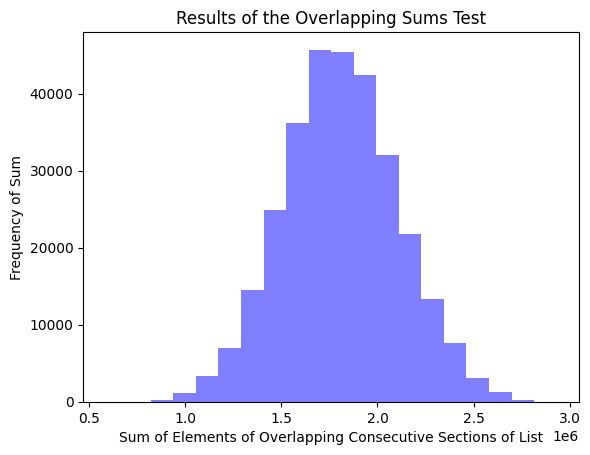

In [16]:
import matplotlib.pyplot as plt
overlap = overlapping_sums(list_random(211111,111112,300007),12)
plt.hist(overlap, 20, facecolor = 'blue', alpha = 0.5)
plt.title('Results of the Overlapping Sums Test')
plt.xlabel('Sum of Elements of Overlapping Consecutive Sections of List')
plt.ylabel('Frequency of Sum')
plt.show()

In [17]:
def feedback_shift(bits):
    xor_result = (bits[1] + bits[2]) % 2
    output = bits.pop()
    bits.insert(0,xor_result)
    return(bits,output)

In [18]:
def feedback_shift_list(bits_this):
    bits_output = [bits_this.copy()]
    random_output = []
    bits_next = bits_this.copy()
    while(len(bits_output) < 2**len(bits_this)):
        bits_next,next = feedback_shift(bits_next)
        bits_output.append(bits_next.copy())
        random_output.append(next)
    return(bits_output,random_output)

In [19]:
bitslist = feedback_shift_list([1,1,1])[0]

In [20]:
bitslist

[[1, 1, 1],
 [0, 1, 1],
 [0, 0, 1],
 [1, 0, 0],
 [0, 1, 0],
 [1, 0, 1],
 [1, 1, 0],
 [1, 1, 1]]

In [21]:
pseudorandom_bits = feedback_shift_list([1,1,1])[1]

In [22]:
pseudorandom_bits

[1, 1, 1, 0, 0, 1, 0]